# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 4</span>

### Exercise 04.1

In Statistical Mechanics the Maxwell–Boltzmann distribution (<a href="https://en.wikipedia.org/wiki/Maxwell%E2%80%93Boltzmann_distribution" target="_blank">Link Wikipedia</a>) is a probability distribution used for describing particle speeds in idealized gases. However, rarefied gases at ordinary temperatures behave very nearly like an ideal gas and the Maxwell–Boltzmann speed distribution is an excellent approximation for such gases. For a 3D system its formula is:
$$p(v,T) = \left( \frac{m}{2\pi k_B T} \right)^{3/2} 4\pi v^2 e^{-\frac{m v^2}{2 k_B T}}$$

By using LJ reduced units (Lenght: $\sigma$; Energy: $\epsilon$; Mass: the mass, $m$, of the particles; Temperature: $\epsilon/k_B$; velocity: $\sqrt{\epsilon/m}$) its form becomes:
$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

The NSL_SIMULATOR code already computes the total (internal) energy per particle, $E/N$, the potential energy per particle, $U/N$, the kinetic energy per particle, $K/N$, the temperature, $T$, and the pressure, $P$.

<span style="color:red">Include the calculation of the Maxwell–Boltzmann distribution, $p(v^*,T^*)$, inside your Molecular Dynamics code by using data blocking to obtain single block averages, progressive average values and progressive uncertainties for $p(v^*,T^*)$.</span>

Remember that, the Maxwell–Boltzmann distribution, $p(v^*,T^*)$, can be approximately computed as a **normalized histogram** on an appropriate interval $\left[ 0, v_{max}\right]$ and chosing the number of bins into which you want to divide this interval.

La velocita massima scelta da vedere nel grafico l'ho fissata a $v_{max} = 8$

Questa scelta fissa anche la larghezza dei bin dell'istogramma, in quanto vale la relazione $\text{bin-size}_v = v_{max} / \text{n-bins}_v$ dove il numero di bins è un parametro di input $= 30$

### Exercise 04.2

By means of your upgraded code, <span style="color:red">perform MD simulations via a Lennard-Jones model</span> ( e.g. Argon parameters: $\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- gas phase: $\rho^\star = 0.05$, $T^\star \sim  2.0$ (cut-off radius: $r_c = 5.0$)

starting from a <span style="color:red">**very low entropic** initial configuration</span>:
1. initial **particle positions**: <span style="color:red">fcc crystal occupying half of the simulation box in each dimension</span>
2. initial **velocity distribution**: <span style="color:red">$p_\delta(v^*,T^*) = \delta\left( v^* - v_{T^*}\right)$</span> where $v_{T^*}$ is suitably connected to $T^*$. For example, this condition could be obtained by imposing that every particle has an initial velocity $\pm v_{T^*}$ for **only one** of its velocity components: $v_x$, $v_y$, $v_z$.

The goal is to show that, by evolving such initial condition via a Molecular Dynamics simulation, the velocity distribution tends to approximate the Maxwell–Boltzmann distribution.

- **Produce some pictures that show this convergence**
- The evolution of the system moves towards the increasing of entropy (more homeogeneous configuration of particles)? What would you find by changing the direction of time? Comment on these aspects in your jupyter-notebook

**Note that** the MD simulation will conserve the total energy; thus the kinetic energy and the temperature are not constant of motion ... the comparison should be done with $p(v^*,T^*_{\rm eff})$ where $T^*_{\rm eff}$ is the effective temperature obtained once the system has been equilibrated.

Per generare una distribuzione delle velocità che sia una delta di dirac ho svolto i seguenti passaggi:

- Calcolato la velocità desiderata come $v^* = \sqrt{T^*}$
- Al fine di assicurare che il momento totale del sistema sia nullo ho assegnato la velocità alle particelle a coppie (nelle 6 direzioni cartesiane in modo randomico) in modo che se la prima particella ha una velocità $v_i = +v^*$ lungo un asse cartersiano allora la seconda particella avrà velocità $v_{i+1} = -v^*$. In questo modo, dal momento che le particelle sono pari il momento totale del sistema è sicuramente nullo.

In [1]:
def previsione_teorica(v, T):
    return (1./(2 * np.pi* T)**(3./2.)) * (4 * np.pi * (v**2) * np.exp( - (v**2) / (2. * T) ))

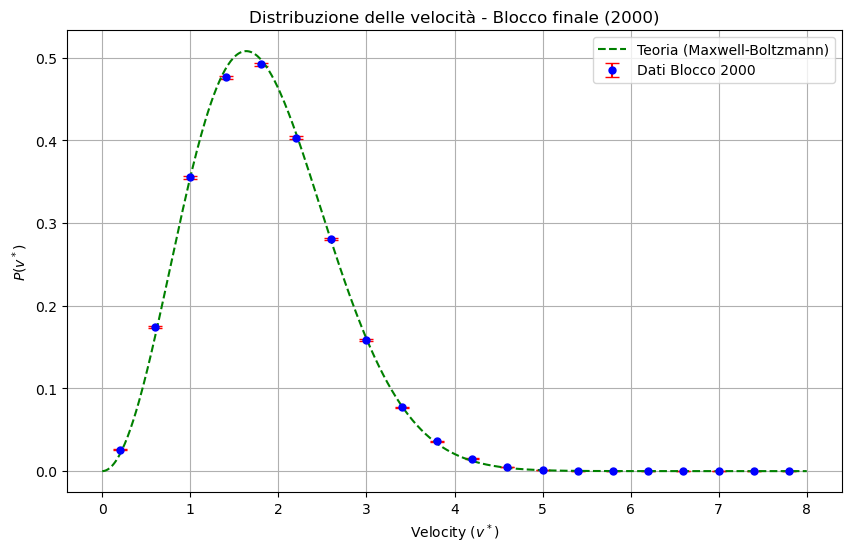

In [4]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('pofv.dat')

ultimo_blocco = data[-1, 0] 

mask = (data[:, 0] == ultimo_blocco)
ultimo_dato = data[mask]

v   = ultimo_dato[:, 2]
p   = ultimo_dato[:, 4]
err = ultimo_dato[:, 5]

plt.figure(figsize=(10, 6))
plt.errorbar(v, p, yerr=err, color='blue', ecolor='red', capsize=5, fmt='o', markersize=5, label=f'Dati Blocco {int(ultimo_blocco)}')
T_star = t_final
v_teorica = np.linspace(0, 8, 500)
p_teorica = previsione_teorica(v_teorica, T_star)
plt.plot(v_teorica, p_teorica, 'g--', label='Teoria (Maxwell-Boltzmann)')
plt.xlabel('Velocity ($v^*$)')
plt.ylabel('$P(v^*)$')
plt.title(f'Distribuzione delle velocità - Blocco finale ({int(ultimo_blocco)})')
plt.legend()
plt.grid(True)
plt.show()

Nel grafico precedente possiamo notare una chiara convergenza della distribuzione delle velocità del sistema alla distribuzione di Maxwell-Boltzmann alla temperatura a cui il sistema ha termalizzato. Infatti l'evoluzione dinamica ottenuta mediante l'integrazione di Verlet ha fatto sì che le interazioni tra le particelle ridistribuissero l'energia cinetica in modo isotropo su tutti i gradi di libertà del sistema. 
Questo ha causato il fatto che il sistema abbia dimenticato la sua configurazione iniziale ordianata a bassa entropia, evolvendo spontaneamente verso lo stato più probabile, caratterizzato proprio dalla distribuzione di Maxwell-Boltzmann.

Nel grafico successivo possiamo notare innanzitutto la termalizzazione del sistema a sinistra. Poiche il sistema parte da una temperatura iniziale più alta e termalizza a una temperatura finale più bassa, l'energia cinetica $E_K \sim k_B\,T$ va a diminuire. Questo comporta un'aumento dell'energia potenziale del sistema (l'energia totale deve rimanere costante). Chiaramente i grafici dell'energia (tutti quelli presenti in questo notebook) sono caratterizzati da offset diversi sia nell'energia potenziale sia nell'energia cinetica per facilitare la visualizzazione dei grafici.

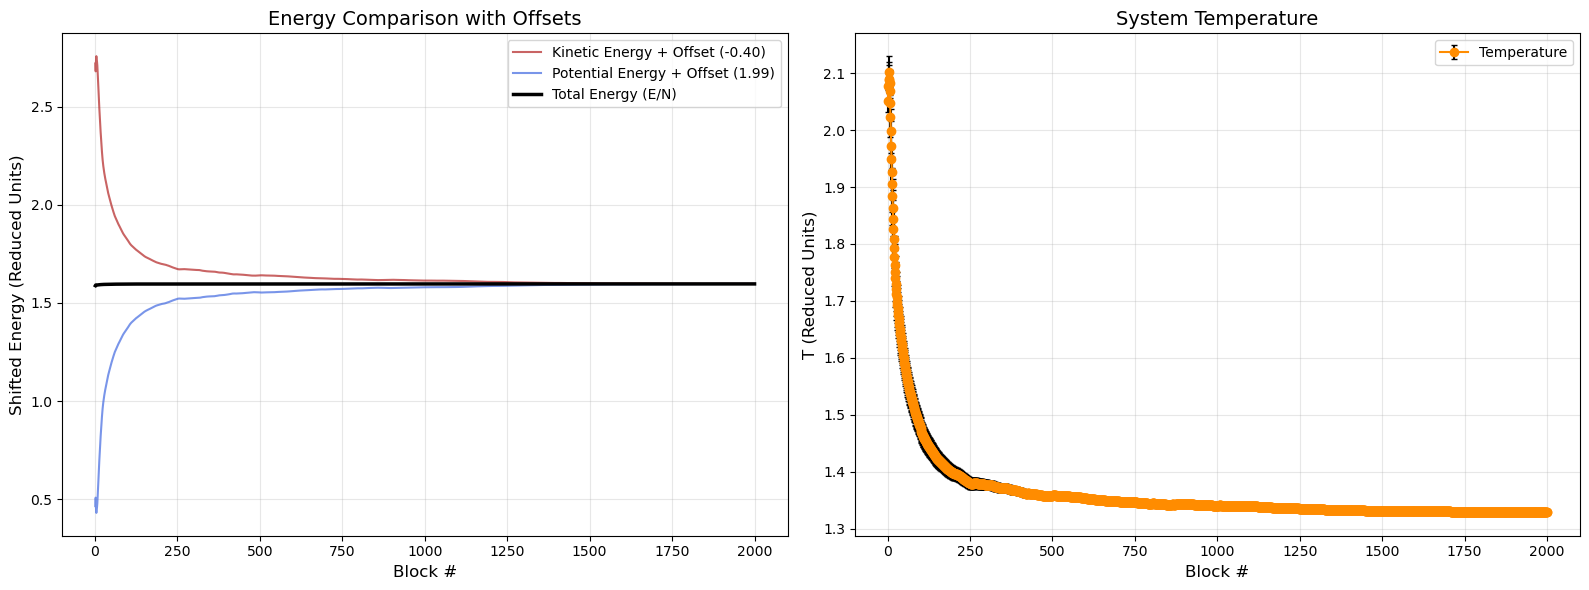

In [23]:
import matplotlib.pyplot as plt
import numpy as np

ke = np.loadtxt('kinetic_energy2')
pe = np.loadtxt('potential_energy2')
te = np.loadtxt('total_energy2')
temp = np.loadtxt('temperature2')

target_energy = te[-1, 2]
offset_ke = target_energy - ke[-1, 2]
offset_pe = target_energy - pe[-1, 2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(ke[:,0], ke[:,2] + offset_ke, label=f'Kinetic Energy + Offset ({offset_ke:.2f})', color='firebrick', alpha=0.7)
ax1.plot(pe[:,0], pe[:,2] + offset_pe, label=f'Potential Energy + Offset ({offset_pe:.2f})', color='royalblue', alpha=0.7)
ax1.plot(te[:,0], te[:,2], label='Total Energy (E/N)', color='black', linewidth=2.5)
ax1.set_title('Energy Comparison with Offsets', fontsize=14)
ax1.set_xlabel('Block #', fontsize=12)
ax1.set_ylabel('Shifted Energy (Reduced Units)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.errorbar(temp[:,0], temp[:,2], yerr=temp[:,3], color='darkorange', ecolor='black', capsize = 2, fmt = '-o', label='Temperature')
ax2.set_title('System Temperature', fontsize=14)
ax2.set_xlabel('Block #', fontsize=12)
ax2.set_ylabel('T (Reduced Units)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
n_ultimi_blocchi = 100
ultime_medie = temp[-n_ultimi_blocchi:, 2]
t_final = np.mean(ultime_medie)

print(f"--- ANALISI TERMALIZZAZIONE ---")
print(f"Temperatura media (ultimi {n_ultimi_blocchi} blocchi): {t_final:.4f}")

--- ANALISI TERMALIZZAZIONE ---
Temperatura media (ultimi 100 blocchi): 1.3293


Di seguito l'evoluzione temporale della distribuzione della velocità del sistema al variare dei blocchi. Possiamo notare come inizialmente la distribuzione sia una delta di dirac piccata in $v^*$. All'aumetare dei blocchi il sistema evolve in configurazioni più probabili, che aumentano l'entropia del sistema, raggiungendo piuttosto velocemente la configurazione che caratterizza la distribuzione di velocità di Maxwell-Boltzmann

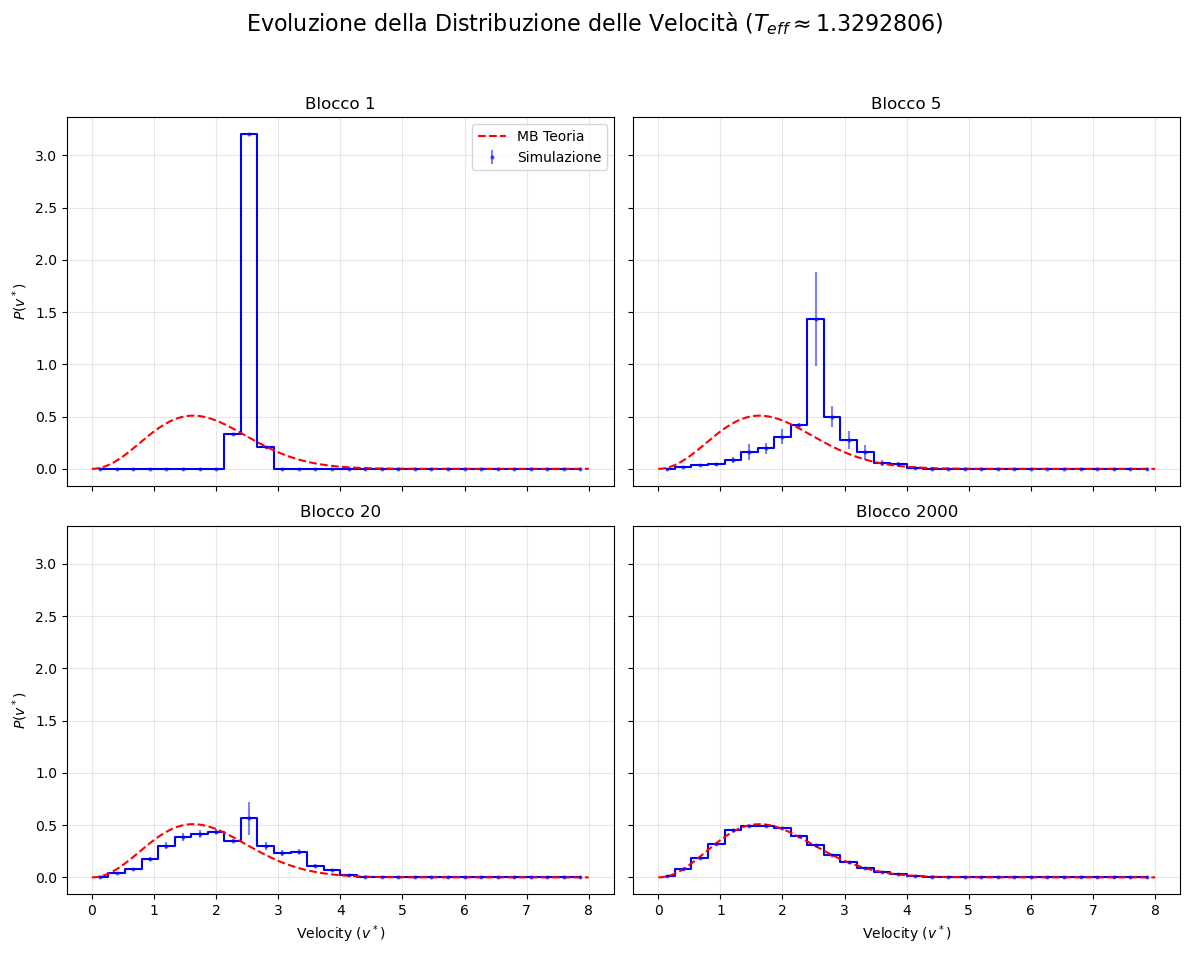

In [8]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('pofv2')
n_blocks = int(data[-1, 0])
blocchi_scelti = [1, 5, 20, n_blocks]
T_eff = t_final 

fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axs = axs.flatten()

for i, blk in enumerate(blocchi_scelti):
    mask = (data[:, 0] == blk)
    subset = data[mask]
    v = subset[:, 2]
    p = subset[:, 4] 
    err = subset[:, 5]

    axs[i].errorbar(v, p, yerr=err, fmt='o', markersize=2, color='blue', alpha=0.5, label='Simulazione')
    axs[i].step(v, p, where='mid', color='blue')
    v_teorica = np.linspace(0, 8, 200)
    axs[i].plot(v_teorica, previsione_teorica(v_teorica, T_eff), 'r--', label='MB Teoria')
    axs[i].set_title(f'Blocco {blk}')
    axs[i].grid(True, alpha=0.3)
    if i == 0: axs[i].legend()

fig.suptitle(f'Evoluzione della Distribuzione delle Velocità ($T_{{eff}} \\approx {T_eff}$)', fontsize=16)
for ax in axs[2:]: ax.set_xlabel('Velocity ($v^*$)')
for ax in [axs[0], axs[2]]: ax.set_ylabel('$P(v^*)$')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Nel caso si dovesse eseguire un'azione di inversione temporale, mi aspetto che, essendo la dinamica del sistema guidata dall'integrazione da parte dell'algoritmo di Verlet delle equazioni del moto ed essendo le stesse matematicamente reversibili, il sistema dovrebbe ritornare alla configurazione iniziale a bassa entropia (in contraddizione con il secondo principio della termodinamica, essendo il sistema isolato). Tuttavia va preso anche in considerazione come l'algoritmo di Verlet non sia un metodo esatto: è anch'esso soggeto a un errore a ogni passo di integrazione. Tali errori di integrazione fanno sì che il sistema non ritorni esattamente nello stato di configurazione iniziale ma in uno stato a entropia maggiore. Tuttavia, approfondendo questo argomento, anche se il sistema riuscisse ad avere un meccanismo di integrazione perfetta e riuscisse a tornare esattamente nella configurazione iniziale, non si verificherebbe un paradosso. Infatti nel momento stesso in cui vado a invertire le velocità, il sistema (che a prima vista risulterebbe isolato) si accoppia con l'ambiente (il mio computer). Infatti nel momento stesso in cui vado inserire la configurazione finale come configurazione input dell'inversione temporale, viene generato calore che viene dissipato nell'ambiente, aumentando l'entropia dell'universo. In questo modo viene salvato il secondo principio della termodinamica. Questo argomento che ho cercato di spiegare applicato a questa simulazione di dinamica molecolare è conosciuto come **Principio di Landauer**.

### Exercise 04.3

Starting from the final state of an **equilibrated** MD simulation of the system in Exercise 04.2, by changing the direction of time (e.g. by inverting the final velocities, i.e. ... ), try to return back to the very low entropic initial configuration of Exercise 04.2. Is this possible? (for example, one can monitor the behavior of the average **potential energy** and the average **temperature** in **each block** as a function of time going **in both directions**. Show some picture and comment on what you find in your jupyter-notebook.

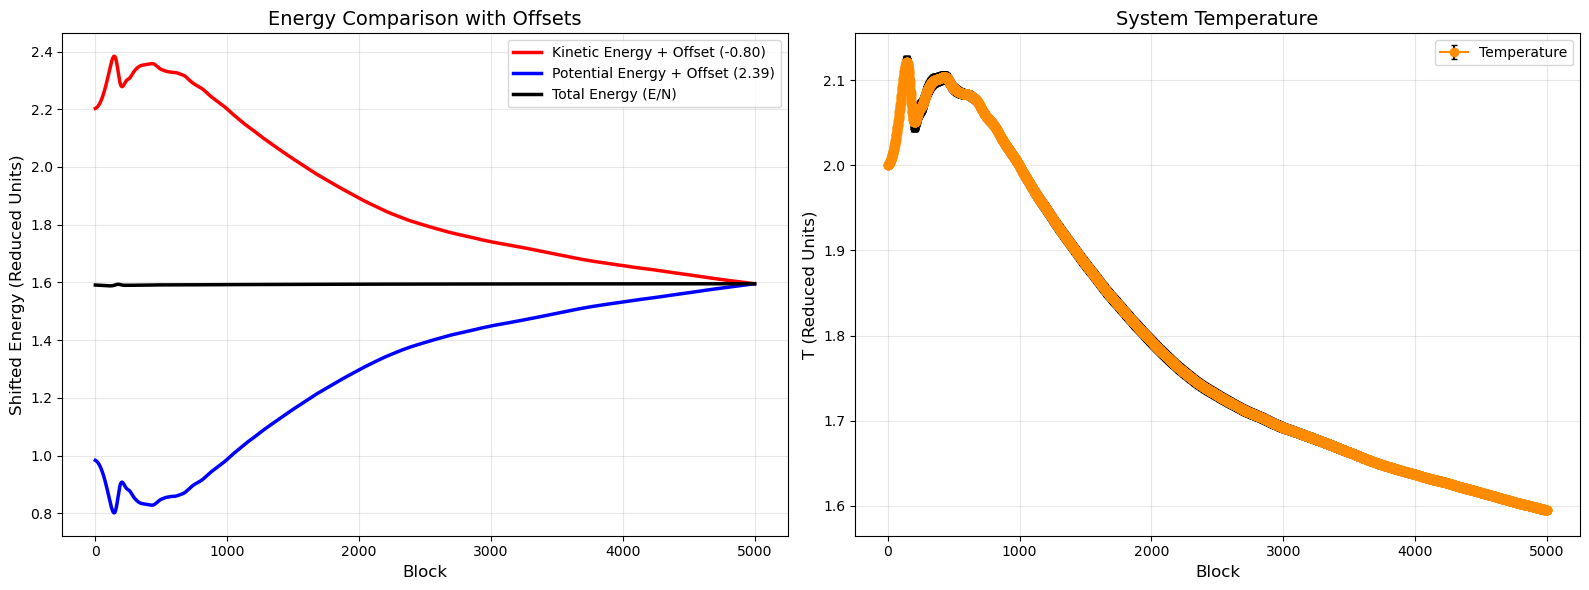

In [9]:
import matplotlib.pyplot as plt
import numpy as np

ke = np.loadtxt('kinetic_energy_andata')
pe = np.loadtxt('potential_energy_andata')
te = np.loadtxt('total_energy_andata')
temp = np.loadtxt('temperature_andata')

target_energy = te[-1, 2]
offset_ke = target_energy - ke[-1, 2]
offset_pe = target_energy - pe[-1, 2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(ke[:,0], ke[:,2] + offset_ke, label=f'Kinetic Energy + Offset ({offset_ke:.2f})', color='red', linewidth=2.5)
ax1.plot(pe[:,0], pe[:,2] + offset_pe, label=f'Potential Energy + Offset ({offset_pe:.2f})', color='blue', linewidth=2.5)
ax1.plot(te[:,0], te[:,2], label='Total Energy (E/N)', color='black', linewidth=2.5)
ax1.set_title('Energy Comparison with Offsets', fontsize=14)
ax1.set_xlabel('Block', fontsize=12)
ax1.set_ylabel('Shifted Energy (Reduced Units)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.errorbar(temp[:,0], temp[:,2], yerr=temp[:,3], color='darkorange', ecolor='black', capsize = 2, fmt = '-o', label='Temperature')
ax2.set_title('System Temperature', fontsize=14)
ax2.set_xlabel('Block', fontsize=12)
ax2.set_ylabel('T (Reduced Units)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


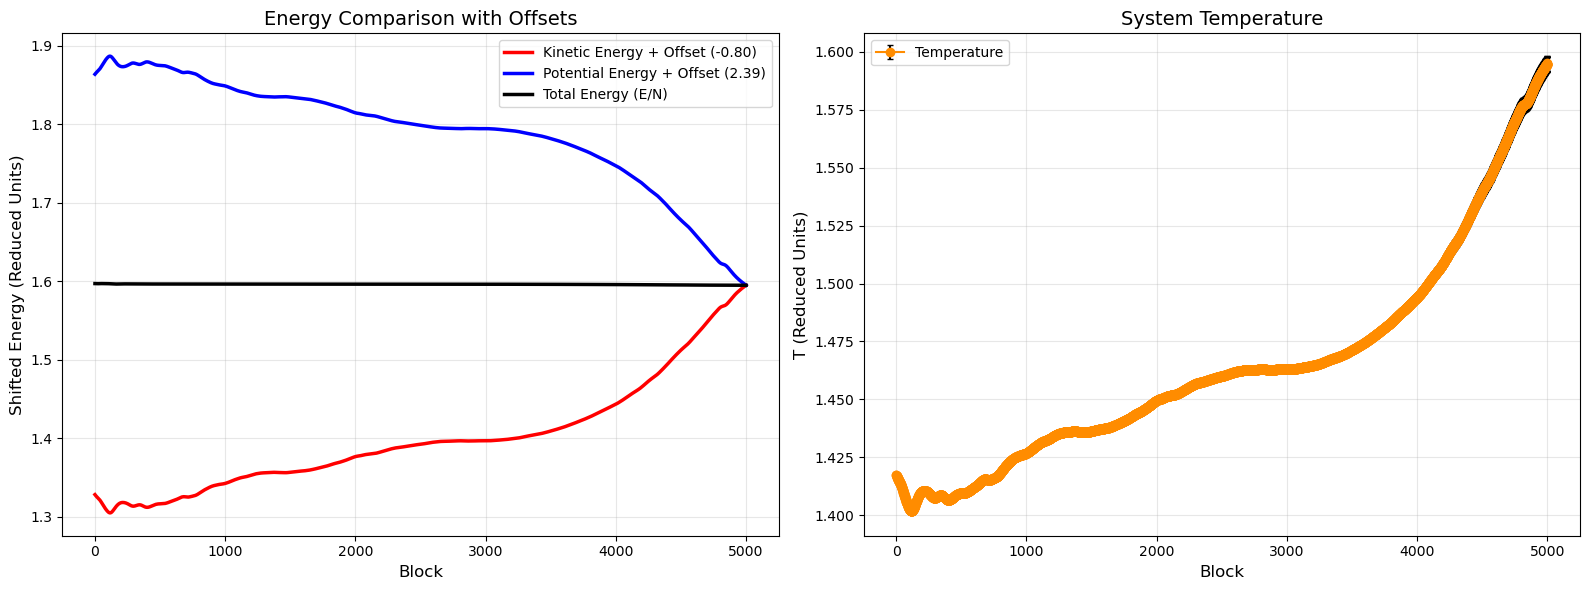

In [10]:
import matplotlib.pyplot as plt
import numpy as np

ke = np.loadtxt('kinetic_energy_ritorno')
pe = np.loadtxt('potential_energy_ritorno')
te = np.loadtxt('total_energy_ritorno')
temp = np.loadtxt('temperature_ritorno')

target_energy = te[-1, 2]
offset_ke = target_energy - ke[-1, 2]
offset_pe = target_energy - pe[-1, 2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(ke[:,0], ke[:,2] + offset_ke, label=f'Kinetic Energy + Offset ({offset_ke:.2f})', color='red', linewidth=2.5)
ax1.plot(pe[:,0], pe[:,2] + offset_pe, label=f'Potential Energy + Offset ({offset_pe:.2f})', color='blue', linewidth=2.5)
ax1.plot(te[:,0], te[:,2], label='Total Energy (E/N)', color='black', linewidth=2.5)
ax1.set_title('Energy Comparison with Offsets', fontsize=14)
ax1.set_xlabel('Block', fontsize=12)
ax1.set_ylabel('Shifted Energy (Reduced Units)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.errorbar(temp[:,0], temp[:,2], yerr=temp[:,3], color='darkorange', ecolor='black', capsize = 2, fmt = '-o', label='Temperature')
ax2.set_title('System Temperature', fontsize=14)
ax2.set_xlabel('Block', fontsize=12)
ax2.set_ylabel('T (Reduced Units)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

I grafici soprastanti mostrano come non ci sia una grande simmetria per invesione temporale. Infatti la diminuzione e l'aumento dell'energia cinetica (e l'aumento e la diminuzione dell'energia potenziale) non risultano simmetrici. Inoltre anche la temperatura non viene restaurata, indice del fatto che lo stato finale ottenuto ha entropia maggiore rispetto allo stato a bassa entropia di partenza, correttamente in accordo con le previsioni precendenti.

In [11]:
from IPython.display import Video

Video("andata.mp4", width=800)

In [12]:
Video("ritorno.mp4", width=800)

I video soprastanti mostrano la dinamica delle particelle. Il primo video è la classica evoluzione dallo stato ordinato fcc a bassa entropia fino allo stato disordinato finale. Il secondo video parte dallo stato finale del primo video a cui viene applicata l'operazione di invesione temporale. Possiamo notare che dal punto di vista dinamico il sistema sembri tornare in una configurazione molto simile e ordianata a quella di partenza. Tuttavia a causa degli errori di integrazione menzionati prima dell'algoritmo di Verlet, il sistema non ritorna esattamente nella configuarazione fcc iniziale.